# Machine Learning Modeling

This notebook trains and evaluates multiple machine learning models.

In [1]:
import pandas as pd
import numpy as np

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

import matplotlib.pyplot as plt

In [2]:
X_train = pd.read_csv("../data/processed/X_train.csv")
X_test = pd.read_csv("../data/processed/X_test.csv")

y_train = pd.read_csv("../data/processed/y_train.csv").squeeze()
y_test = pd.read_csv("../data/processed/y_test.csv").squeeze()

## Logistic Regression

In [3]:
lr = LogisticRegression()

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

In [4]:
print(classification_report(y_test, lr_pred))

              precision    recall  f1-score   support

           0       0.87      0.99      0.92       682
           1       0.66      0.15      0.25       123

    accuracy                           0.86       805
   macro avg       0.76      0.57      0.59       805
weighted avg       0.83      0.86      0.82       805



## Random Forest

In [7]:
rf = RandomForestClassifier(
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

In [8]:
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.86      0.96      0.91       682
           1       0.38      0.12      0.19       123

    accuracy                           0.84       805
   macro avg       0.62      0.54      0.55       805
weighted avg       0.79      0.84      0.80       805



## Decision Tree

In [12]:
dt = DecisionTreeClassifier(
    random_state=42
)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

print(classification_report(y_test, dt_pred))

              precision    recall  f1-score   support

           0       0.87      0.85      0.86       682
           1       0.26      0.28      0.27       123

    accuracy                           0.77       805
   macro avg       0.56      0.57      0.57       805
weighted avg       0.78      0.77      0.77       805



## Model Comparison

In [9]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ]
})

results

,Model
0,Logistic Regression
1,Decision Tree
2,Random Forest


## Feature Importance

In [10]:
importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    "Importance",
    ascending=False
)

importance.head(10)

,Feature,Importance
12,12,0.167822
0,0,0.167790
7,7,0.161103
10,10,0.129860
11,11,0.100237
2,2,0.059940
5,5,0.044818
3,3,0.040872
9,9,0.031016
4,4,0.030413


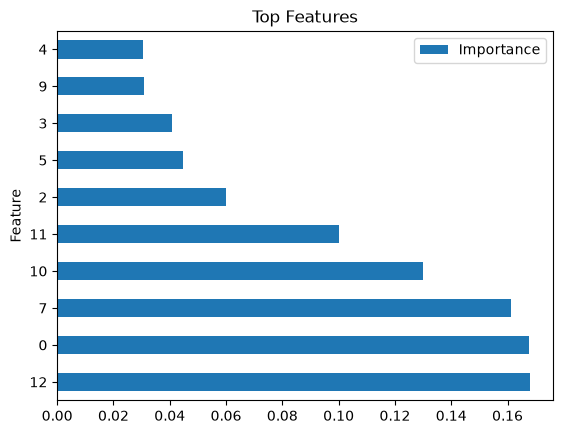

In [11]:
importance.head(10).plot(
    kind="barh",
    x="Feature",
    y="Importance"
)

plt.title("Top Features")

plt.show()